# **Exploratory Data Analysis**

## **Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## **Load Data**

### **Perkenalan Dataset**

**Sumber Dataset**:

- Dataset diperoleh dari data pengumpulan sensor IoT yang diunduh dari platform IoT Cloud Thingspeak

In [3]:
df = pd.read_csv(r'..\data\raw\ENV_data_2025-06-16_to_2025-06-22.csv')

df

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-16 11:07:01+07:00,25.7,84.6,24.2,35.9,NaN,NaN
1,2025-06-17 14:02:31+07:00,25.9,73.6,23.1,32.3,NaN,NaN
2,2025-06-17 14:03:21+07:00,25.9,73.4,25.3,35.9,NaN,NaN
3,2025-06-17 14:04:10+07:00,25.9,72.9,25.7,36.2,NaN,NaN
4,2025-06-17 14:04:59+07:00,25.9,74.4,26.6,35.3,NaN,NaN
...,...,...,...,...,...,...,...
7757,2025-06-22 06:56:14+07:00,25.1,90.0,73.4,100.3,0.53338,404.14658
7758,2025-06-22 06:57:03+07:00,25.2,88.9,79.7,111.2,0.55777,404.04834
7759,2025-06-22 06:57:53+07:00,25.2,88.5,84.1,115.3,0.55777,403.86526
7760,2025-06-22 06:58:42+07:00,25.2,88.5,82.1,111.2,0.58302,403.80316


In [4]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [5]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

## **Exploratory Data Analysis**

In [6]:
df['created_at'] = pd.to_datetime(df['created_at'])

C:\Users\Muhammad Mahdi\AppData\Local\Temp\ipykernel_26432\329245698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['created_at'] = pd.to_datetime(df['created_at'])


In [7]:
df = df.set_index('created_at')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7755 entries, 2025-06-17 14:08:50+07:00 to 2025-06-22 06:59:32+07:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  7755 non-null   float64
 1   Humidity     7755 non-null   float64
 2   PM2.5        7755 non-null   float64
 3   PM10         7755 non-null   float64
 4   CO           7755 non-null   float64
 5   CO2          7755 non-null   float64
dtypes: float64(6)
memory usage: 424.1 KB


In [9]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,CO,CO2
count,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,26.758904,78.613694,43.242012,57.000129,1.881124,403.906187
std,1.112280,5.291232,38.345703,48.762572,1.230806,0.860725
min,24.100000,64.000000,8.700000,10.900000,0.370100,400.787660
25%,26.000000,75.100000,16.400000,21.900000,0.614490,403.293330
50%,26.700000,78.300000,30.400000,43.300000,1.588430,403.719120
75%,27.600000,81.100000,57.000000,72.650000,2.768360,404.247010
max,29.600000,91.600000,778.099980,862.500000,6.114610,409.802520


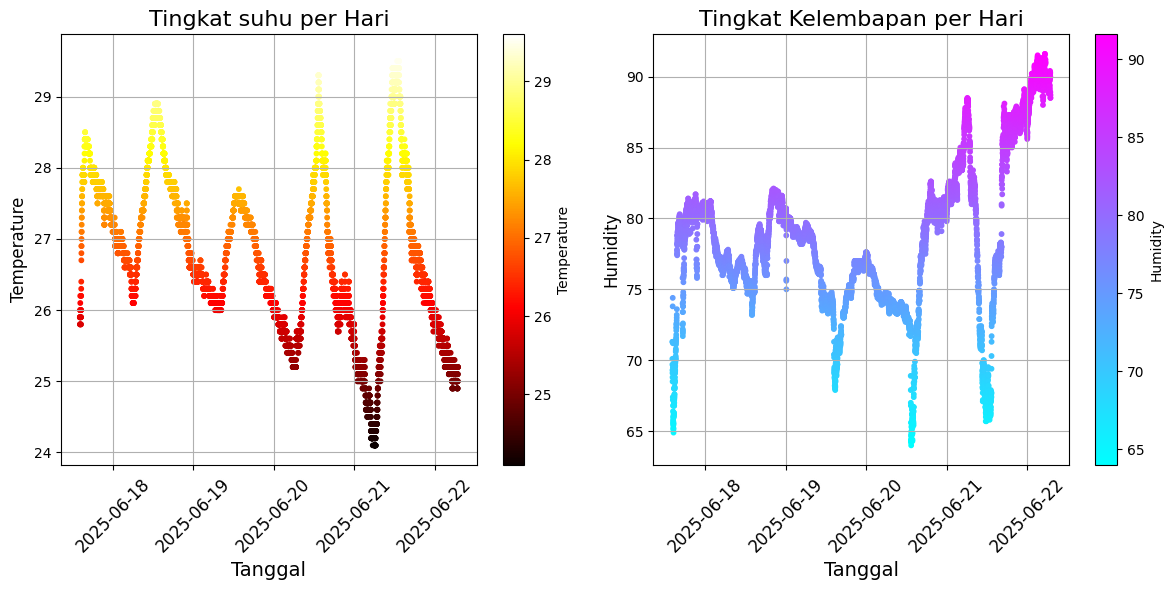

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.scatter(df.index, df['Temperature'], c=df['Temperature'], cmap='hot', s=10)
plt.title('Tingkat suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Temperature', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Temperature')
plt.grid(True)

plt.subplot(122)
plt.scatter(df.index, df['Humidity'], c=df['Humidity'], cmap='cool', s=10)
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Humidity', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Humidity')
plt.grid(True)

plt.tight_layout()
plt.show()

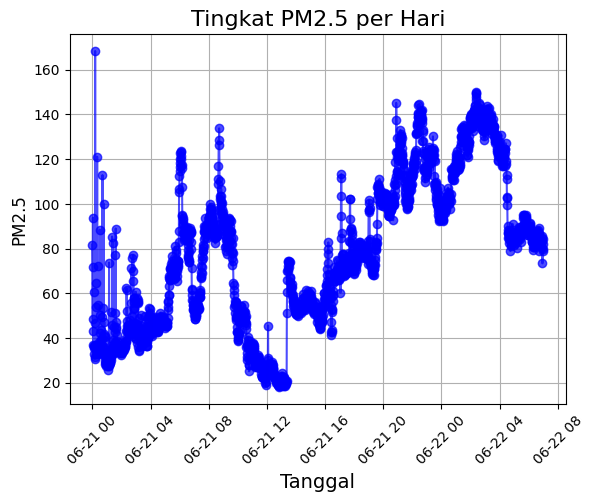

In [18]:
plt.plot(df['PM2.5']['2025-06-21':'2025-06-22'], marker='o', color='blue', alpha=0.7)
plt.title('Tingkat PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.tick_params(axis='x', rotation=45)
plt.grid(True)

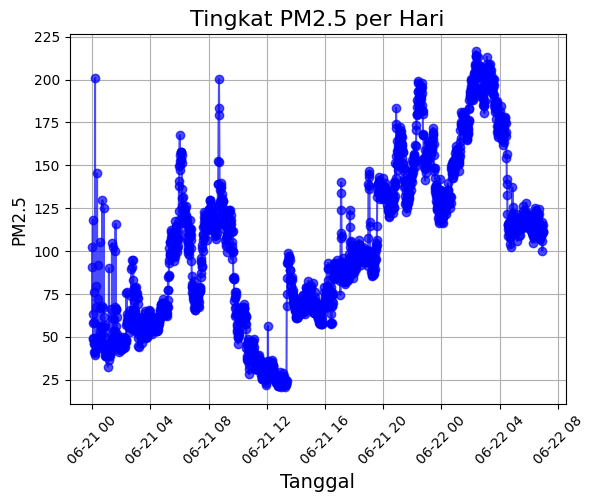

In [20]:
plt.plot(df['PM10']['2025-06-21':'2025-06-22'], marker='o', color='blue', alpha=0.7)
plt.title('Tingkat PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.tick_params(axis='x', rotation=45)
plt.grid(True)

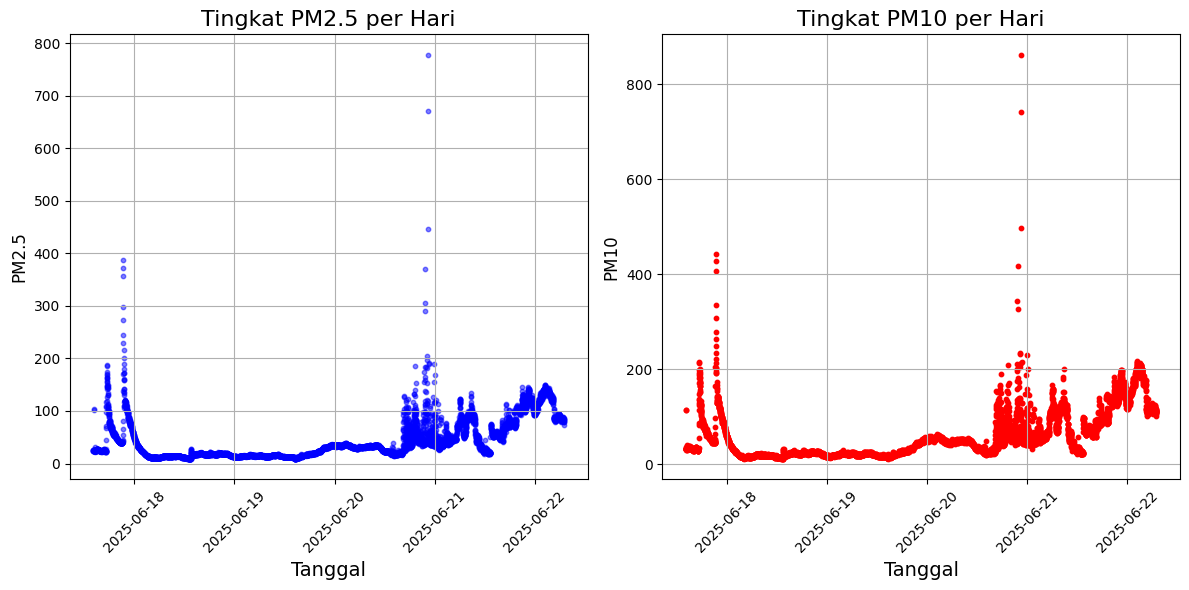

In [12]:
plt.figure(figsize=(12, 6))

ax1 = plt.subplot(121)
ax1.scatter(df.index, df['PM2.5'], s=10, c='blue', alpha=0.5)
ax1.set_title('Tingkat PM2.5 per Hari', fontsize=16)
ax1.set_xlabel('Tanggal', fontsize=14)
ax1.set_ylabel('PM2.5', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

ax2 = plt.subplot(122)
ax2.scatter(df.index, df['PM10'], s=10, c='red')
ax2.set_title('Tingkat PM10 per Hari', fontsize=16)
ax2.set_xlabel('Tanggal', fontsize=14)
ax2.set_ylabel('PM10', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)


plt.tight_layout()
plt.show()

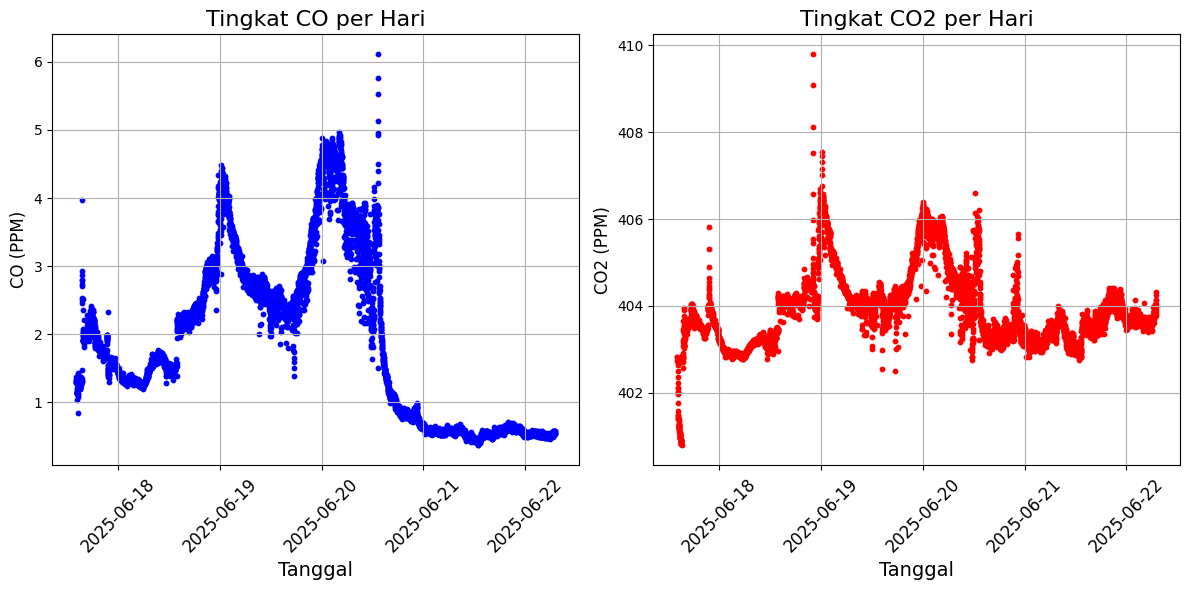

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.scatter(df.index, df['CO'], s=10, color='blue')
plt.title('Tingkat CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO (PPM)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.grid(True)

plt.subplot(122)
plt.scatter(df.index, df['CO2'], s=10, color='red')
plt.title('Tingkat CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2 (PPM)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

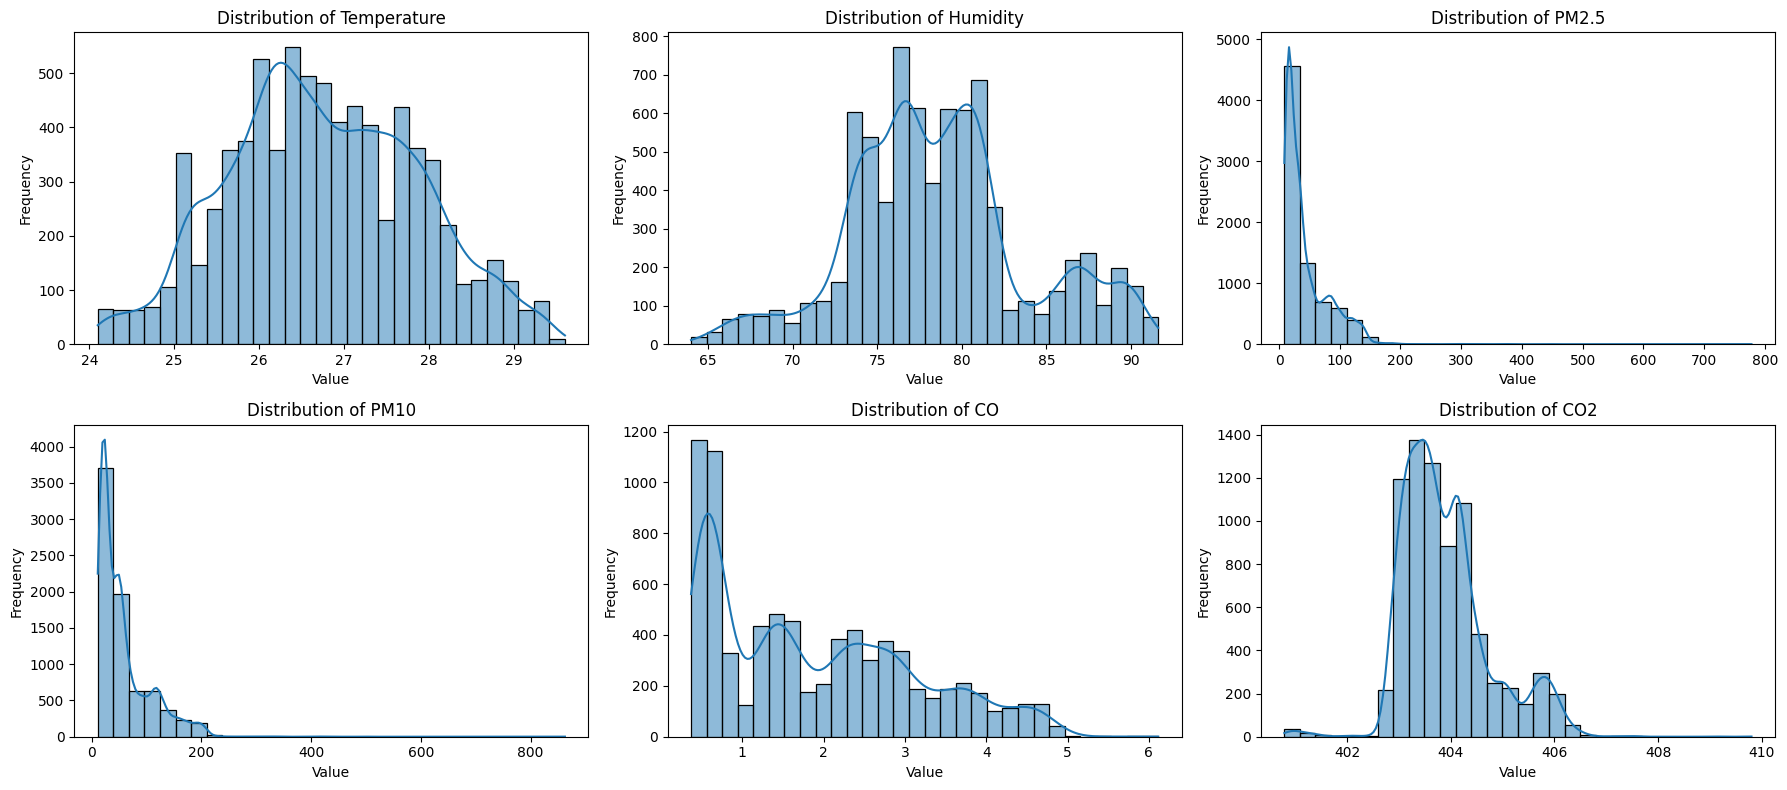

In [14]:
# Daftar nama kolom
columns_to_plot = df.columns.tolist()
 
# Menentukan jumlah baris dan kolom untuk subplot()
n_cols = 3  # Jumlah kolom pada grid subplot
n_rows = -(-len(columns_to_plot) // n_cols)  # Ceiling division untuk menentukan jumlah baris

# Membuat kanvas utama
plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Membuat histogram untuk setiap kolom
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)  # Menentukan posisi subplot
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

# Menyesuaikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

In [15]:
df.skew()

Temperature    0.097295
Humidity       0.239587
PM2.5          3.142996
PM10           2.509267
CO             0.587411
CO2            0.806069
dtype: float64

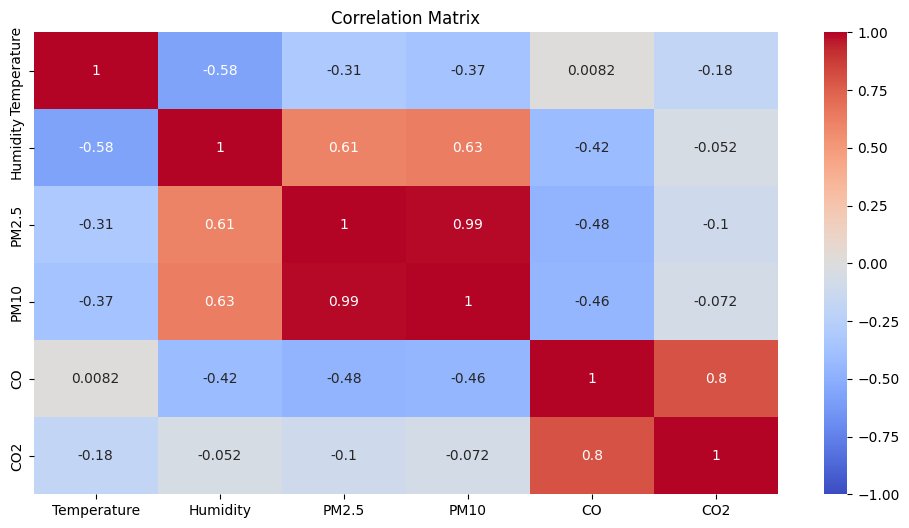

In [16]:
# Visualisasi korelasi antar variabel
plt.figure(figsize=(12, 6))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

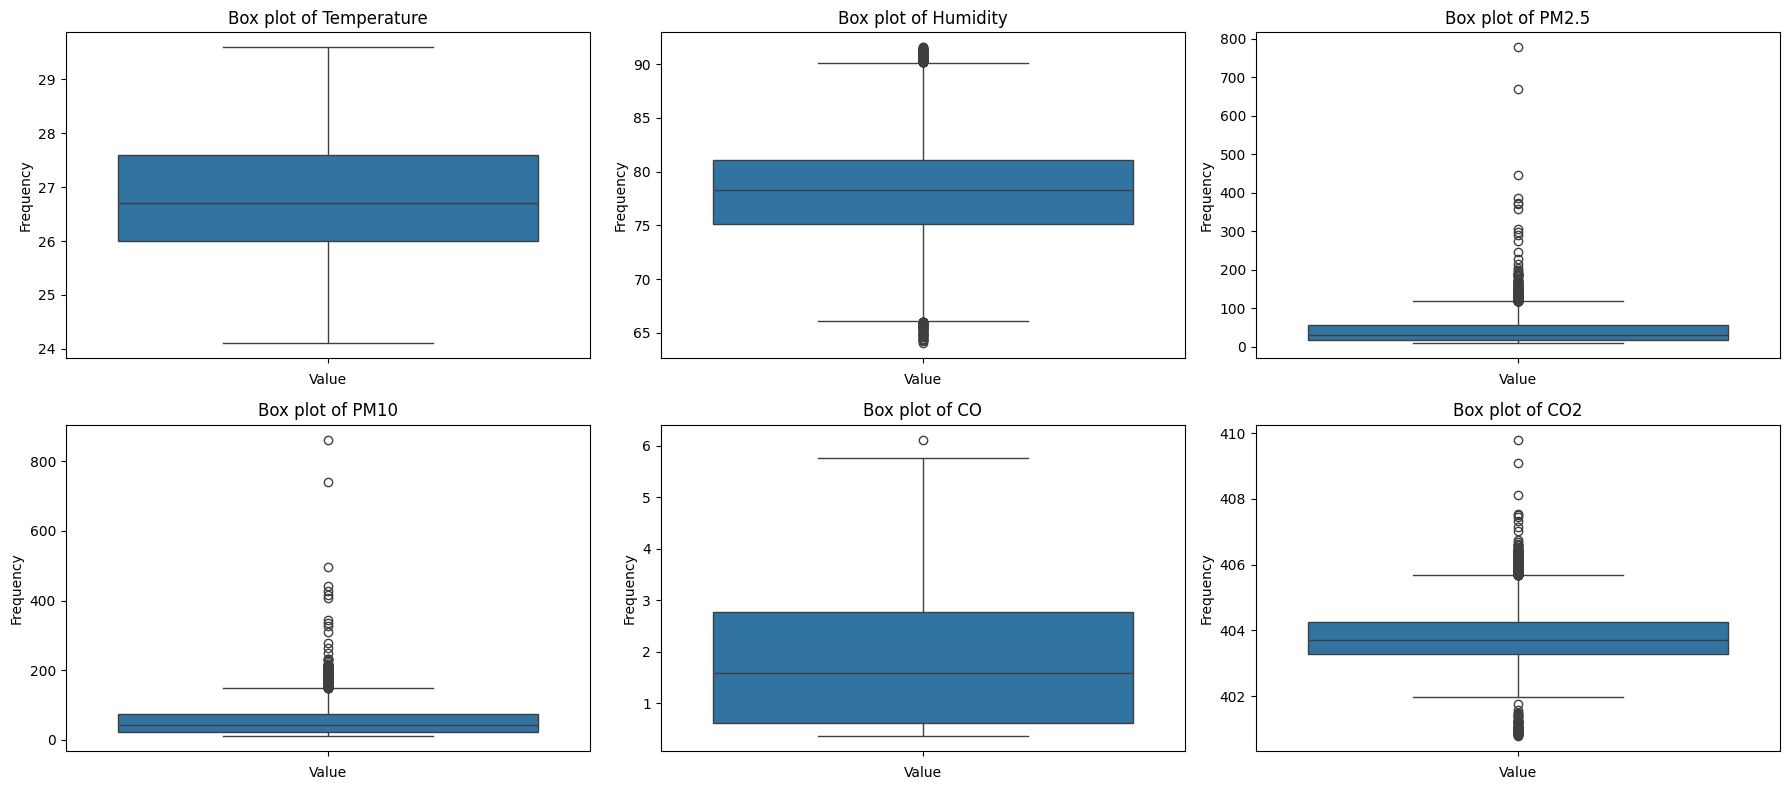

In [17]:
# Daftar nama kolom
columns_to_plot = df.columns.tolist()
 
# Menentukan jumlah baris dan kolom untuk subplot()
n_cols = 3  # Jumlah kolom pada grid subplot
n_rows = -(-len(columns_to_plot) // n_cols)  # Ceiling division untuk menentukan jumlah baris

# Membuat kanvas utama
plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Membuat histogram untuk setiap kolom
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)  # Menentukan posisi subplot
    sns.boxplot(df[column])
    plt.title(f'Box plot of {column}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

# Menyesuaikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

### **Hasil Exploratory Data Analysis (EDA)**

---

#### **created_at**
- Data dikumpulkan mulai tanggal **17 Juni 2025** hingga **22 Juni 2025**.
- Terdapat total **8000 baris data**, dengan interval pencatatan **sekitar 1 menit sekali**.
- Timestamp disesuaikan ke zona waktu **Asia/Jakarta (GMT+7)**.

---

#### **Temperature**
- **Rata-rata (mean)**: 26.76 °C  
- **Minimum**: 24.10 °C  
- **Maksimum**: 29.60 °C  
- **Standar deviasi**: 1.11 °C  
- **Skewness**: 0.097  
  Distribusi **hampir simetris**, menyerupai distribusi normal. Tidak ditemukan outlier ekstrem.

---

#### **Humidity**
- **Rata-rata**: 78.61 %  
- **Minimum**: 64.00 %  
- **Maksimum**: 91.60 %  
- **Standar deviasi**: 5.29 %  
- **Skewness**: 0.240  
  Distribusi **sedikit miring ke kanan**, namun masih dalam batas wajar dan stabil. Kelembapan tinggi mungkin terjadi saat cuaca lembap atau hujan.

---

#### **PM2.5**
- **Rata-rata**: 43.24 µg/m³  
- **Minimum**: 8.70 µg/m³  
- **Maksimum**: 778.10 µg/m³  
- **Standar deviasi**: 38.35 µg/m³  
- **Skewness**: 3.14  
  Distribusi **sangat miring ke kanan (positif skewed)**. Terdapat banyak nilai kecil, namun juga sejumlah outlier besar yang dapat berasal dari polusi berat atau aktivitas ekstrem seperti asap kendaraan atau pembakaran.

---

#### **PM10**
- **Rata-rata**: 57.00 µg/m³  
- **Minimum**: 10.90 µg/m³  
- **Maksimum**: 862.50 µg/m³  
- **Standar deviasi**: 48.76 µg/m³  
- **Skewness**: 2.51  
  Distribusi juga **sangat miring ke kanan**, menunjukkan karakteristik mirip dengan PM2.5. Outlier besar bisa menjadi indikator kualitas udara yang sangat buruk pada waktu tertentu.

---

#### **CO**
- **Rata-rata**: 1.88 ppm  
- **Minimum**: 0.37 ppm  
- **Maksimum**: 6.11 ppm  
- **Standar deviasi**: 1.23 ppm  
- **Skewness**: 0.59  
  Distribusi **moderat miring ke kanan**, menunjukkan konsentrasi CO lebih banyak berada di nilai rendah namun masih ada lonjakan sesekali.

---

#### **CO₂**
- **Rata-rata**: 403.91 ppm  
- **Minimum**: 400.79 ppm  
- **Maksimum**: 409.80 ppm  
- **Standar deviasi**: 0.86 ppm  
- **Skewness**: 0.81  
  Distribusi **cukup simetris namun sedikit miring ke kanan**. Hal ini wajar karena CO₂ cenderung stabil secara alami di atmosfer, namun bisa sedikit meningkat akibat aktivitas manusia.

